In [28]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge


from scipy.stats import wasserstein_distance, spearmanr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
import numpy.ma as ma


from sklearn.utils import resample

import warnings

import seaborn as sns
from astral import moon

from io import BytesIO
from openpyxl.drawing.image import Image


In [29]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
split_year = 2022
min_time, max_time = pd.to_datetime("2009-01-01"), pd.to_datetime("2025-12-31")
sp = "HKP"
fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = np.log1p(effort)
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
# temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
# temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
# chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
# mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
# depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
# zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
# so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
# ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
# vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
# pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
# cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
# spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
# zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

times = pd.DatetimeIndex(temp.time.values)

moon_ = np.array([moon.phase(t) for t in times])
moon_phase = xr.DataArray(moon_, coords={"time": temp.time}, dims=["time"], name="moon_phase")
# moon_phase = (moon_phase - moon_phase.mean()) / moon_phase.std()
moon_phase = moon_phase.fillna(0)
moon_phase = moon_phase.broadcast_like(temp)


year = temp["time"].dt.year
# year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = temp["lat"]
lon = temp["lon"]
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd, moon_phase = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, moon_phase, join="inner")

fishing, peso, effort, mask = xr.align(fishing, peso, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)
peso = croppedT(peso)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)
moon_phase = cropped(moon_phase)

(204, 11, 62, 25)
(204, 30, 17)
(204, 30, 17)
      feature        VIF
8          PP  17.329176
7         CHL   9.752904
0          to   9.225734
10  month_cos   4.193871
9   month_sin   4.034131
1          so   3.877207
5      mlotst   2.482482
6         CDM   2.129026
2          zo   1.488800
3         vgo   1.468275
4         ugo   1.303343
Suggested variables to drop: ['PP']


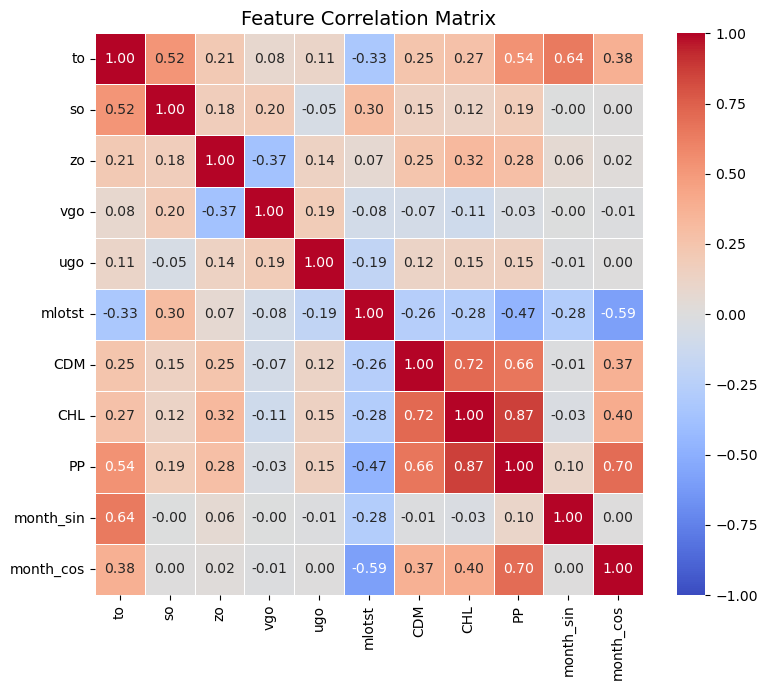

torch.Size([144, 12, 11, 62, 25])
torch.Size([144, 30, 17])
torch.Size([36, 12, 11, 62, 25])
torch.Size([36, 30, 17])


In [30]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so,  zo, #temp_bottom,
         ugo, vgo, mixed,
         cdm, chl,  pp,
         month_sin, month_cos,
        #  year,
        # month,
        # moon_phase,
        # lat, lon,
        # depth,
        ]

vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)



train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))

# -------- Data Standardization (Z-score Normalization) --------
# 1. Assign your variable names to the channel coordinate for explicit targeting
train_X = train_X.assign_coords(channel=vars_names)
test_X  = test_X.assign_coords(channel=vars_names)
epsilon = 1e-8 #avoids division by zero

# 2. Calculate mean and standard deviation across space and time
train_mean = train_X.mean(dim=["time", "lat", "lon"], skipna=True)
train_std  = train_X.std(dim=["time", "lat", "lon"], skipna=True)


# 3. Set mean=0 and std=1 for cyclical features so they bypass scaling
# (Subtracting 1e-8 ensures the denominator becomes exactly 1.0 when epsilon is added)
for feat in ["month_sin", "month_cos"]:
    if feat in train_mean.coords["channel"].values:
        train_mean.loc[dict(channel=feat)] = 0.0
        train_std.loc[dict(channel=feat)] = 1.0 - epsilon

# 4. Apply the transformation natively across the entire DataArray
train_X = (train_X - train_mean) / (train_std + epsilon)
test_X  = (test_X - train_mean) / (train_std + epsilon)


# -------- Check correlations --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
#inflation factor
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))
#correlation matrix
corr_matrix = df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.75)]
print(f"Suggested variables to drop: {to_drop}")
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", fmt=".2f",vmin=-1,vmax=1, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()



def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(X_test.shape)  # (N, T, C, H, W)
print(y_test.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)



In [31]:
def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays 
    compatible with scikit-learn Random Forest. Handles both Torch tensors and Numpy arrays.
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)

H_out_test, W_out_test = y_test.shape[1], y_test.shape[2]

m_true = m_test_ml.reshape(-1, H_out_test, W_out_test)
y_true = y_test_ml.reshape(-1, H_out_test, W_out_test)

mask_flat = m_test_ml.astype(bool)


In [32]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat = y_pred_flat.flatten()
    
    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)
    

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    print(f"\n--- Total hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Hit Rate                        : {hit_rate_percent:.4f}%")

    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")



    # =====================================================
    # YEARLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80

    yearly_hit_rates = []

    # Iterate through time in 12-month chunks
    for year_idx in range(0, y_true.shape[0], 12):
        end_idx = min(year_idx + 12, y_true.shape[0])

        if mask_spatial.ndim == 3:
            current_mask = mask_spatial[year_idx:end_idx].astype(bool)

            y_true_year = y_true[year_idx:end_idx][current_mask]
            y_pred_year = y_pred3D_temp[year_idx:end_idx][current_mask]

        else:
            current_mask = mask_spatial.astype(bool)

            y_true_year = y_true[year_idx:end_idx][:, current_mask].flatten()
            y_pred_year = y_pred3D_temp[year_idx:end_idx][:, current_mask].flatten()

        # Skip empty years
        if len(y_true_year) == 0:
            continue

        # Year-specific top 20% thresholds
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)

        actual_hotspots_year = y_true_year >= thresh_true_year
        pred_hotspots_year = y_pred_year >= thresh_pred_year

        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)

        if total_actual_year > 0:
            yearly_hit_rates.append((shared_year / total_actual_year) * 100)

    mean_yearly_hit_rate = np.mean(yearly_hit_rates) if yearly_hit_rates else 0
    print(f"Mean Yearly Hit Rate                : {mean_yearly_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # Reshape to 3D
    # =====================================================
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D = y_pred_flat.reshape(-1, H_out, W_out)
    mask_spatial = mask_spatial.astype(bool)

    # =====================================================
    # SSIM
    # =====================================================
    data_range = (y_true[mask_spatial].max()-y_true[mask_spatial].min())

    ssim_scores = []

    for i in range(y_true.shape[0]):

        _, ssim_map = ssim(
            y_true[i],
            y_pred3D[i],
            data_range=data_range,
            win_size=5,
            full=True
        )

        valid_ssim_pixels = ssim_map[mask_spatial[i]]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # PLOTTING
    # =====================================================

    y_true_m = np.where(mask_spatial, y_true, 0)
    y_pred_m = np.where(mask_spatial, y_pred3D, 0)

    # 2. Compute means. The masked array automatically ignores the hidden values!
    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
 
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_true_m2 = ma.masked_where(~mask_spatial, y_true)
    y_pred_m2 = ma.masked_where(~mask_spatial, y_pred3D)
    y_pred_plot2 = y_pred_m2.mean(axis=(1, 2))
    y_true_plot2 = y_true_m2.mean(axis=(1, 2))
    
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(y_true_plot2, label="Real")
    ax.plot(y_pred_plot2, label="Predicho")
    ax.set_ylabel("Valor Promedio")
    
    ax.annotate(f"R2: {r2_plot2:.3f}",xy=(0.98, 0.02),xycoords="axes fraction",ha="right",va="bottom",)
    ax.set_xlabel("Tiempo (Meses)")
    ax.legend()

    plt.show()
    
    metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr, hit_rate_percent, mean_yearly_hit_rate, mean_monthly_hit_rate]
    columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
    metrics_df = pd.DataFrame(columns=columns)
    metrics_df.loc[len(metrics_df)] = metrics

    return metrics_df, fig

RMSE: 1.7784
Normalized RMSE: 0.1516 (15.16%)
MAE: 1.2205
R2: 0.5359
Pearson R: 0.7461
MBE: -0.3282
Wasserstein Distance: 0.8947
Spearman Rank Correlation: 0.71

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 54.6667%
Mean Monthly Hit Rate               : 39.844%
Mean Yearly Hit Rate                : 53.111%
-------------------------------------------------

Mean Masked SSIM: 0.5233



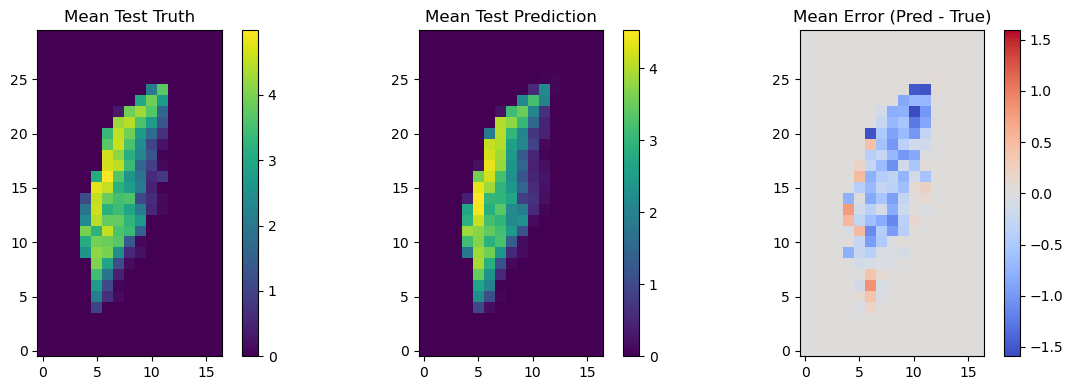

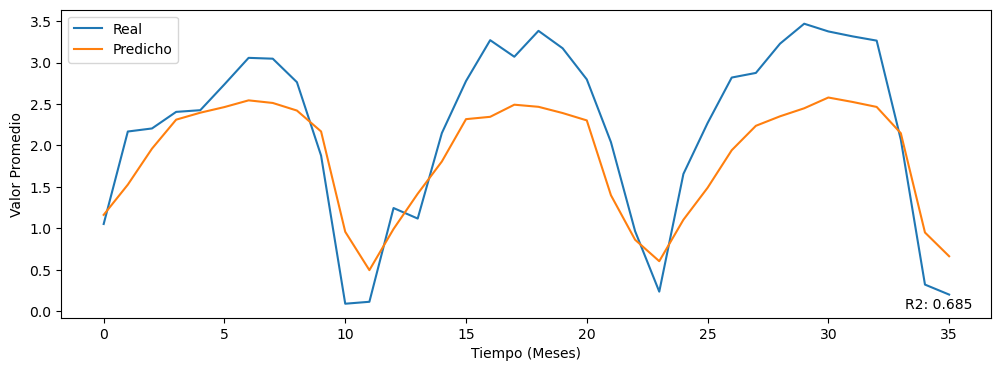

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.535863,0.746057,0.685401,0.523268,1.778443,0.15164,1.220502,-0.328166,0.894686,0.71411,54.666667,53.111111,39.84439


     Variable  Importance
0          to    0.185247
1          so    0.125384
2      mlotst    0.124736
3          PP    0.111665
4         CDM    0.083832
5          zo    0.083403
6         vgo    0.079837
7         CHL    0.078128
8         ugo    0.077357
9   month_cos    0.025413
10  month_sin    0.025000


In [33]:
model = RandomForestRegressor(n_estimators=100, max_features="sqrt", n_jobs=-1, random_state=42)

model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# -------- Feature Importance Extraction --------
raw_importances = model.feature_importances_
T = X_train.shape[1]   # window (12)
C = X_train.shape[2]   # number of variables/channels
H_x = X_train.shape[3] # height (lat)
W_x = X_train.shape[4] # width (lon)

reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Importance': variable_importances
})

# Sort in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()


img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    importance_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")


# # 1. Take a tiny subset of test data
# sample_size = int(len(X_test_ml) / 5)
# X_test_subset = X_test_ml[:sample_size] 

# # Initialize explainer with background data
# background = X_train_ml[:sample_size]
# explainer = shap.TreeExplainer(model, data=background)

# print("Computing SHAP values")
# # Shape: (samples, flattened_features, outputs)
# shap_values_multi = explainer.shap_values(X_test_subset)

# # 2. Average the SHAP impact across the target predicted pixels (axis=2)
# shap_values_mean_output = np.mean(shap_values_multi, axis=2) 
# # Shape is now: (samples, T * C * H_x * W_x)

# # 3. Reshape back to your exact 5D spatial-temporal structure
# samples = X_test_subset.shape[0]
# T = X_train.shape[1]
# C = X_train.shape[2]
# H_x = X_train.shape[3]
# W_x = X_train.shape[4]

# shap_reshaped = shap_values_mean_output.reshape(samples, T, C, H_x, W_x)
# X_reshaped = X_test_subset.reshape(samples, T, C, H_x, W_x)

# # 4. Aggregate across Time (axis 1), Lat (axis 3), and Lon (axis 4)
# # SUM the SHAP values to get the total contribution of each variable
# shap_aggregated = np.sum(shap_reshaped, axis=(1, 3, 4))  # Shape: (samples, C)

# # MEAN the actual feature values to correctly color the dots (High/Low)
# X_aggregated = np.mean(X_reshaped, axis=(1, 3, 4))       # Shape: (samples, C)

# # 5. Generate the summary beeswarm plot mapping perfectly to vars_names
# explanation = shap.Explanation(
#     values=shap_aggregated,
#     data=X_aggregated,
#     feature_names=vars_names  # Now it perfectly matches ['temp', 'so', 'mixed', ...]
# )

# plt.figure(figsize=(12, 8))
# # max_display=len(vars_names) ensures every base variable is shown
# shap.plots.beeswarm(explanation, max_display=len(vars_names), show=False)
# plt.title("Overall SHAP Summary per Variable (Aggregated across Space & Time)", fontsize=14, pad=20)
# plt.tight_layout()
# plt.show()

RMSE: 1.7785
Normalized RMSE: 0.1516 (15.16%)
MAE: 1.2048
R2: 0.5358
Pearson R: 0.7440
MBE: -0.3163
Wasserstein Distance: 0.8612
Spearman Rank Correlation: 0.71

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 53.8889%
Mean Monthly Hit Rate               : 38.400%
Mean Yearly Hit Rate                : 52.667%
-------------------------------------------------

Mean Masked SSIM: 0.5275



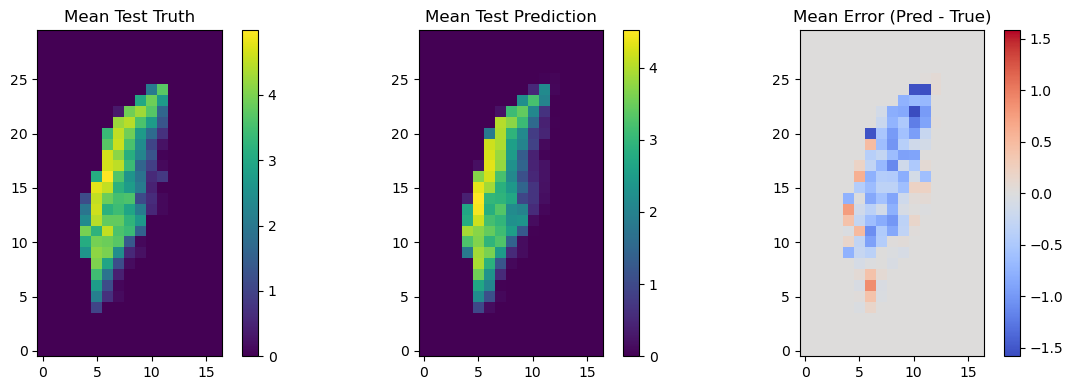

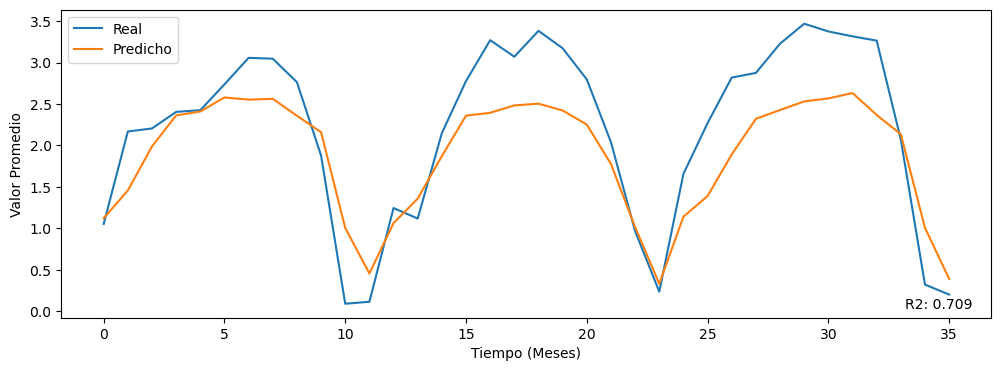

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.535833,0.744038,0.709399,0.527459,1.7785,0.151645,1.204781,-0.316317,0.861198,0.71179,53.888889,52.666667,38.399945


In [34]:
model = ExtraTreesRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")

RMSE: 1.8284
Normalized RMSE: 0.1559 (15.59%)
MAE: 1.2155
R2: 0.5094
Pearson R: 0.7305
MBE: -0.3931
Wasserstein Distance: 0.8670
Spearman Rank Correlation: 0.70

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 53.7778%
Mean Monthly Hit Rate               : 39.092%
Mean Yearly Hit Rate                : 52.556%
-------------------------------------------------

Mean Masked SSIM: 0.5085



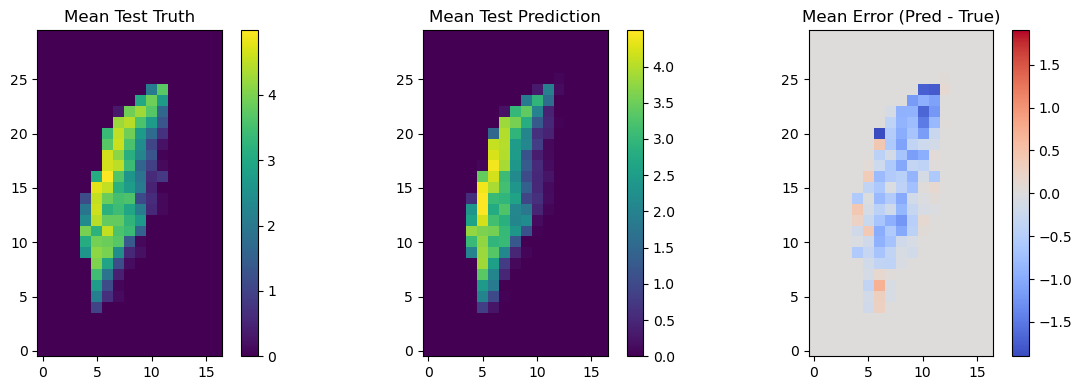

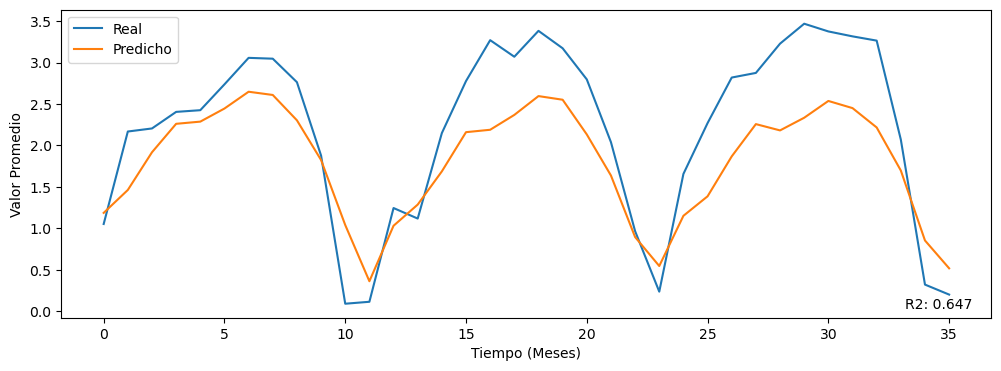

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.509438,0.730466,0.647382,0.508537,1.828369,0.155897,1.215519,-0.393079,0.86703,0.70346,53.777778,52.555556,39.091637


In [35]:
model = KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)
metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")



RMSE: 1.9545
Normalized RMSE: 0.1666 (16.66%)
MAE: 1.3394
R2: 0.4394
Pearson R: 0.6783
MBE: -0.2872
Wasserstein Distance: 0.8121
Spearman Rank Correlation: 0.65

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 52.0000%
Mean Monthly Hit Rate               : 39.054%
Mean Yearly Hit Rate                : 50.778%
-------------------------------------------------

Mean Masked SSIM: 0.4747



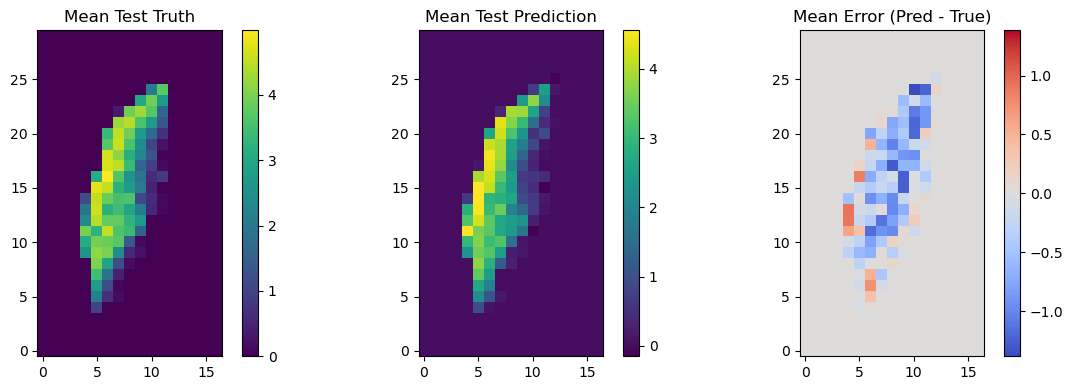

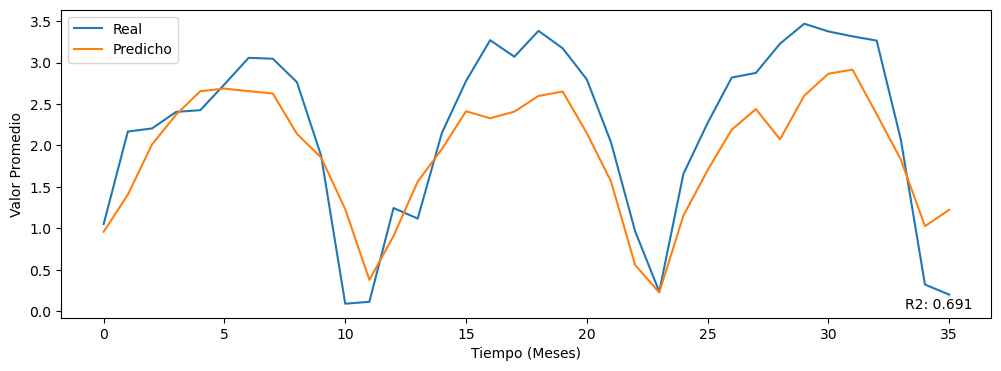

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.439436,0.678268,0.690655,0.474726,1.954473,0.16665,1.339357,-0.287207,0.812124,0.650307,52.0,50.777778,39.053533


Running 50 bootstrap iterations


c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\linear_model\_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.00868e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\linear_model\_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.8483e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\linear_model\_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.37743e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\linear_model\_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.57441e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\ruba


--- Ridge (L2) Bootstrapped Significance Report ---
     Variable  Significant_Grid_Ratio  Overall_Impact     Direction
9   month_sin                0.500000        0.033279  Positive (+)
10  month_cos                0.500000        0.033279  Negative (-)
1          so                0.373011        0.011841  Negative (-)
6         CDM                0.309301        0.428740  Negative (-)
2          zo                0.267796        0.122120  Positive (+)
0          to                0.261882        0.132014  Positive (+)
5      mlotst                0.230269        0.335525  Negative (-)
8          PP                0.181828        0.265315  Positive (+)
7         CHL                0.167903        0.349058  Positive (+)
4         ugo                0.164247        0.266128  Negative (-)
3         vgo                0.151129        0.193074  Positive (+)


In [36]:
ridge_model = Ridge(alpha=1.0, solver='auto', random_state=42)
ridge_model.fit(X_train_ml, y_train_ml)

y_pred_flat = ridge_model.predict(X_test_ml)
metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# -------- Bootstrapping for Statistical metrics --------
warnings.filterwarnings("ignore", message="Singular matrix in solving dual problem") # Suppress the specific warning 

n_iterations = 50  
n_features = X_train_ml.shape[1]
bootstrapped_coefs = np.zeros((n_iterations, n_features), dtype=np.float32)

print(f"Running {n_iterations} bootstrap iterations")

for i in range(n_iterations):
    X_boot, y_boot = resample(X_train_ml, y_train_ml, random_state=i)
    boot_model = Ridge(alpha=1.0, solver='auto', random_state=i)
    boot_model.fit(X_boot, y_boot)
    bootstrapped_coefs[i, :] = boot_model.coef_.mean(axis=0)

# -------- Advanced Statistical Feature Extraction (Confidence Intervals) --------

# Calculate the 2.5th and 97.5th percentiles to build a 95% Confidence Interval
# This acts as our mathematical surrogate for a two-tailed p < 0.05 threshold
lower_bound = np.percentile(bootstrapped_coefs, 2.5, axis=0)
upper_bound = np.percentile(bootstrapped_coefs, 97.5, axis=0)

# A feature is statistically stable/significant if its 95% CI does not cross zero
# (meaning it is strictly positive or strictly negative across 95% of resamples)
is_significant = (lower_bound > 0) | (upper_bound < 0)

# -------- Reshaping & Grid Aggregation --------

# Extract and average coefficients from your baseline full-dataset model
raw_ridge_coefs = ridge_model.coef_.mean(axis=0)

# Reshape both baseline weights and the significance mask back to the 5D spatiotemporal grid
reshaped_ridge_coefs = raw_ridge_coefs.reshape(T, C, H_x, W_x)
reshaped_significance = is_significant.reshape(T, C, H_x, W_x)

# Calculate final aggregated metrics across dimensions (T, H_x, W_x)
# Significant_Grid_Ratio: % of the spatiotemporal domain where the variable is significant
significant_grid_ratio = reshaped_significance.mean(axis=(0, 2, 3))
global_ridge_weights = np.abs(reshaped_ridge_coefs).sum(axis=(0, 2, 3))
global_ridge_direction = np.sign(reshaped_ridge_coefs.mean(axis=(0, 2, 3)))

direction_labels = ['Positive (+)' if d > 0 else 'Negative (-)' for d in global_ridge_direction]

# Compile the final statistical report
ridge_importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Significant_Grid_Ratio': significant_grid_ratio,
    'Overall_Impact': global_ridge_weights,
    'Direction': direction_labels
})

print("\n--- Ridge (L2) Bootstrapped Significance Report ---")
print(ridge_importance_df.sort_values(by='Significant_Grid_Ratio', ascending=False))

# save everyhtng to a excel workbook
model_name = ridge_model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ridge_importance_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")